# CME Futures: Backtest & Signal Evaluation

**Chapter 16 — Strategy Simulation**

CME futures operate on a weekly cadence across 30 commodity products in 7
sectors (equity index, treasuries, energy, metals, currencies, agriculture,
livestock). The signal combines carry - the roll yield embedded in the futures
term structure - with momentum. After ratio back-adjustment, most linear
models produce weakly *negative* validation IC (family average -0.015); GBM
lifts to a best daily-pooled IC of +0.025, and the latent-factor **SDF** model
is the one family whose IC clears zero under HAC inference (+0.042 on the
5-day label, +0.070 daily-pooled on the 21-day variant).

This notebook runs the full Ch16 pipeline:

1. **Plumbing test** — verify the backtest engine produces no spurious alpha
2. **Parametric sweep** — test all (prediction × signal method) combinations
3. **Statistical analysis** — DSR, family comparison, IC-vs-Sharpe relationship

Sections 1–2 generate new backtest results (write to registry). Section 3
is read-only — it queries the registry via `BacktestExplorer` and can be
re-run independently without re-running the sweep.

**Data note**: Labels and backtest prices use ratio back-adjusted continuous
contracts (multiplicative adjustment at roll points), so the carry signal is
measured against returns free of the price discontinuities at roll transitions.

**Book Reference:** Chapter 16, Sections 16.4–16.8

**Prerequisites:** Completed model training (Ch11–15) for this case study.

In [1]:
"""Ch16 Backtest & Signal Evaluation — CME Futures case study."""

import time
import warnings

import polars as pl

warnings.filterwarnings("ignore")

from case_studies.utils.backtest_loaders import (
    get_backtest_config,
    load_backtest_prices_for,
    load_contract_specs_from_yaml,
)
from case_studies.utils.backtest_presets import build_backtest_spec, serializable_backtest_spec
from case_studies.utils.backtest_runner import (
    normalize_prediction_columns,
    run_backtest,
    run_plumbing_test,
)
from case_studies.utils.registry import (
    backtest_hash_from_parts,
    load_existing_backtest_hashes,
    load_prediction_index,
    read_predictions,
)
from case_studies.utils.sweep_config import get_entry_schemes_for, get_top_n_predictions
from utils.paths import get_case_study_dir

In [2]:
CASE_STUDY_ID = "cme_futures"
LABEL = ""
SPLIT = "validation"
TOP_K = 20
MAX_SYMBOLS = 0
FORCE_REBACKTEST = False  # Set True to re-backtest even if a complete backtest_hash exists
TOP_N_PREDICTIONS = None

## 1. Setup & Plumbing Test

Before sweeping real predictions, we verify the pipeline is clean. A random
signal over 30 commodity futures should produce Sharpe $\approx 0$. The
weekly cadence means the plumbing test runs quickly — even 30 products × a
multi-year history covers relatively few rebalance events.

In [3]:
CASE_DIR = get_case_study_dir(CASE_STUDY_ID)
bt_config = get_backtest_config(CASE_STUDY_ID)
if TOP_N_PREDICTIONS is None:
    TOP_N_PREDICTIONS = get_top_n_predictions(CASE_STUDY_ID, "signal")

if not LABEL:
    LABEL = bt_config.primary_label

# Load futures contract specs (multipliers, tick sizes) for correct P&L scaling
CONTRACT_SPECS = load_contract_specs_from_yaml()
_es = CONTRACT_SPECS.get("ES")
print(
    f"Loaded {len(CONTRACT_SPECS)} contract specs (e.g., ES multiplier={_es.multiplier if _es else 'n/a'})"
)

print(f"""=== Protocol Term Sheet ===
  Case study:    {CASE_STUDY_ID}
  Label:         {LABEL}
  Calendar:      {bt_config.calendar}
  Cadence:       {bt_config.cadence}
  Commission:    {bt_config.commission_bps:.1f} bps
  Slippage:      {bt_config.slippage_bps:.1f} bps
  Total cost:    {bt_config.commission_bps + bt_config.slippage_bps:.1f} bps/leg
  Long/short:    {bt_config.long_short}
""")

Loaded 36 contract specs (e.g., ES multiplier=50.0)
=== Protocol Term Sheet ===
  Case study:    cme_futures
  Label:         fwd_ret_5d
  Calendar:      CME
  Cadence:       weekly_friday_close
  Commission:    5.0 bps
  Slippage:      2.0 bps
  Total cost:    7.0 bps/leg
  Long/short:    True



In [4]:
prices = load_backtest_prices_for(CASE_STUDY_ID, LABEL, split="validation", max_symbols=MAX_SYMBOLS)
n_assets = prices["symbol"].n_unique()
print(f"Prices: {len(prices):,} rows, {n_assets} assets")

Prices: 38,394 rows, 30 assets


In [5]:
strategy_spec = build_backtest_spec(
    CASE_STUDY_ID,
    bt_config,
    prices=prices,
    prediction_hash="plumbing_test",
    initial_cash=bt_config.initial_cash,
    chapter="ch16",
    signal={
        "method": "score_weighted_top_k",
        "top_k": TOP_K,
        "long_short": bt_config.long_short,
    },
)

try:
    random_sharpe = run_plumbing_test(
        CASE_STUDY_ID,
        prices,
        strategy_spec,
        top_k=TOP_K,
        initial_cash=bt_config.initial_cash,
        calendar=bt_config.calendar,
        contract_specs=CONTRACT_SPECS,
    )

    status = "PASS" if abs(random_sharpe) < 1.5 else "FAIL"
    print(f"Random signal Sharpe: {random_sharpe:.3f}  [{status}]")

    if abs(random_sharpe) >= 1.5:
        print("WARNING: Random signal produces non-trivial Sharpe — investigate pipeline")
except ValueError as e:
    if "zero variance" in str(e).lower():
        print(f"Plumbing test skipped: {e} (too few assets for meaningful test)")
        random_sharpe = 0.0
    else:
        raise

Random signal Sharpe: -1.107  [PASS]


## 2. Parametric Sweep

Sweep all (prediction × entry scheme) combinations using the **same
`run_backtest()` function** as a single backtest — the sweep is pure
orchestration, not a separate implementation.

With only 30 products in the universe, the top-k concentration choices are
more constrained than in broader equity case studies. Holding 10–20 of 30
products is a meaningful concentration, not diversification.

In [6]:
pred_index = load_prediction_index(
    CASE_STUDY_ID,
    label=LABEL,
    split=SPLIT,
)

if pred_index.is_empty():
    msg = f"No predictions found for {CASE_STUDY_ID}/{LABEL}/{SPLIT}"
    raise RuntimeError(msg)

if TOP_N_PREDICTIONS > 0:
    pred_index = pred_index.head(TOP_N_PREDICTIONS)

n_predictions = len(pred_index)
print(f"Predictions to sweep: {n_predictions}")
ic_min, ic_max = pred_index["ic_mean"].min(), pred_index["ic_mean"].max()
if ic_min is not None:
    print(f"  IC range: {ic_min:.4f} — {ic_max:.4f}")
else:
    print("  IC range: not yet computed")

Predictions to sweep: 63
  IC range: -0.0236 — 0.0419


In [7]:
entry_schemes = get_entry_schemes_for(
    CASE_STUDY_ID, LABEL, n_assets, long_short=bt_config.long_short
)
n_schemes = len(entry_schemes)

print(f"\nEntry schemes ({n_schemes}):")
for es in entry_schemes:
    print(f"  {es['name']}: {es['method']} (top_k={es.get('top_k', '-')})")

total_backtests = n_predictions * n_schemes
print(
    f"\nTotal grid: {n_predictions} predictions × {n_schemes} schemes = {total_backtests} backtests"
)


Entry schemes (2):
  ew_top5: equal_weight_top_k (top_k=5)
  ew_top10: equal_weight_top_k (top_k=10)

Total grid: 63 predictions × 2 schemes = 126 backtests


In [8]:
results = []
t0 = time.time()
failed = 0
skipped = 0
existing_hashes = load_existing_backtest_hashes(CASE_STUDY_ID, stage="signal")
print(f"Existing signal-stage hashes in registry: {len(existing_hashes):,}")

for i, pred_row in enumerate(pred_index.iter_rows(named=True)):
    pred_hash = pred_row["prediction_hash"]
    source = pred_row["source"]
    ic_mean = pred_row["ic_mean"]

    pending_schemes = []

    for j, scheme in enumerate(entry_schemes):
        idx = i * n_schemes + j + 1

        signal = {
            "method": scheme["method"],
            "top_k": scheme.get("top_k", 20),
            "long_short": bt_config.long_short,
        }
        signal.update({k: v for k, v in scheme.items() if k not in ("name", "method")})
        spec = build_backtest_spec(
            CASE_STUDY_ID,
            bt_config,
            prices=prices,
            prediction_hash=pred_hash,
            initial_cash=bt_config.initial_cash,
            chapter="ch16",
            signal=signal,
        )
        backtest_hash = backtest_hash_from_parts(pred_hash, serializable_backtest_spec(spec))
        if backtest_hash in existing_hashes:
            skipped += 1
            continue
        pending_schemes.append((scheme, spec))

    if not pending_schemes:
        continue

    predictions = normalize_prediction_columns(read_predictions(CASE_STUDY_ID, pred_hash))

    for scheme, spec in pending_schemes:
        try:
            result = run_backtest(
                CASE_STUDY_ID,
                pred_hash,
                spec,
                prices=prices,
                predictions=predictions,
                label=LABEL,
                register=True,
                force_rebacktest=FORCE_REBACKTEST,
                initial_cash=bt_config.initial_cash,
                calendar=bt_config.calendar,
                contract_specs=CONTRACT_SPECS,
            )

            results.append(
                {
                    "prediction_hash": pred_hash,
                    "source": source,
                    "ic_mean": ic_mean,
                    "family": pred_row["family"],
                    "config_name": pred_row["config_name"],
                    "signal_method": scheme["name"],
                    "backtest_hash": result.backtest_hash,
                    "sharpe": result.metrics["sharpe"],
                    "total_return": result.metrics["total_return"],
                    "max_drawdown": result.metrics["max_drawdown"],
                    "cagr": result.metrics.get("cagr", 0.0),
                    "volatility": result.metrics.get("volatility", 0.0),
                    "num_trades": result.metrics.get("num_trades", 0),
                }
            )
        except (ValueError, RuntimeError, KeyError) as e:
            failed += 1
            results.append(
                {
                    "prediction_hash": pred_hash,
                    "source": source,
                    "ic_mean": ic_mean,
                    "family": pred_row["family"],
                    "config_name": pred_row["config_name"],
                    "signal_method": scheme["name"],
                    "backtest_hash": None,
                    "sharpe": None,
                    "total_return": None,
                    "max_drawdown": None,
                    "cagr": None,
                    "volatility": None,
                    "num_trades": None,
                }
            )

        if idx % 20 == 0 or idx == total_backtests:
            elapsed = time.time() - t0
            rate = idx / elapsed if elapsed > 0 else 0
            print(
                f"  [{idx}/{total_backtests}] {elapsed:.0f}s ({rate:.1f} bt/s) | failed: {failed}"
            )

elapsed = time.time() - t0
print(
    f"\nSweep complete: {len(results)} backtests in {elapsed:.0f}s ({failed} failed, {skipped} skipped)"
)

Existing signal-stage hashes in registry: 302
  SKIP backtest (complete (hash=3ba631e6f6da)) — reusing cached result
  SKIP backtest (complete (hash=ebc021b07006)) — reusing cached result
  SKIP backtest (complete (hash=90ec2b16fece)) — reusing cached result
  SKIP backtest (complete (hash=ac9bec395edb)) — reusing cached result
  SKIP backtest (complete (hash=65877b332157)) — reusing cached result
  SKIP backtest (complete (hash=cdcb6eb968e7)) — reusing cached result
  SKIP backtest (complete (hash=fe4b17337cf5)) — reusing cached result
  SKIP backtest (complete (hash=8b64a3f33a88)) — reusing cached result
  SKIP backtest (complete (hash=ccad7babc2e3)) — reusing cached result
  SKIP backtest (complete (hash=3bf9179129e7)) — reusing cached result
  SKIP backtest (complete (hash=ea55980fa1b6)) — reusing cached result
  SKIP backtest (complete (hash=c22bac6ade3a)) — reusing cached result


  SKIP backtest (complete (hash=08d1c489a565)) — reusing cached result


  SKIP backtest (complete (hash=72303ad385b2)) — reusing cached result


  SKIP backtest (complete (hash=61654a5742c8)) — reusing cached result
  SKIP backtest (complete (hash=cd8a13def57f)) — reusing cached result
  SKIP backtest (complete (hash=91b6713fe36d)) — reusing cached result
  SKIP backtest (complete (hash=9856d46fa84f)) — reusing cached result
  SKIP backtest (complete (hash=0f3fe6df8c19)) — reusing cached result
  [20/126] 0s (75.8 bt/s) | failed: 0
  SKIP backtest (complete (hash=09e33159356e)) — reusing cached result
  [20/126] 0s (72.5 bt/s) | failed: 0
  SKIP backtest (complete (hash=1de0fe46f56b)) — reusing cached result
  SKIP backtest (complete (hash=25fe78c497fb)) — reusing cached result
  SKIP backtest (complete (hash=91360103c7e6)) — reusing cached result
  SKIP backtest (complete (hash=87b0a2e00ce5)) — reusing cached result
  SKIP backtest (complete (hash=328748d205d6)) — reusing cached result
  SKIP backtest (complete (hash=e3a9e8fd111e)) — reusing cached result
  SKIP backtest (complete (hash=984f7814a270)) — reusing cached result


  SKIP backtest (complete (hash=a108a310dc1e)) — reusing cached result


...

  SKIP backtest (complete (hash=8392882a4d9e)) — reusing cached result


  SKIP backtest (complete (hash=aa449085fa66)) — reusing cached result
  SKIP backtest (complete (hash=27cbd402319b)) — reusing cached result
  SKIP backtest (complete (hash=2d7d764df804)) — reusing cached result
  SKIP backtest (complete (hash=742610c209e7)) — reusing cached result
  SKIP backtest (complete (hash=da2bfa236730)) — reusing cached result
  SKIP backtest (complete (hash=466d972067ff)) — reusing cached result
  SKIP backtest (complete (hash=cd5b2dbe0c83)) — reusing cached result
  SKIP backtest (complete (hash=b13f7a58116f)) — reusing cached result
  SKIP backtest (complete (hash=cc337d28ff38)) — reusing cached result
  SKIP backtest (complete (hash=f7a86f546a3f)) — reusing cached result
  SKIP backtest (complete (hash=cf262f9fda63)) — reusing cached result
  SKIP backtest (complete (hash=62deea33c4dc)) — reusing cached result
  SKIP backtest (complete (hash=f95b2be913e1)) — reusing cached result
  [120/126] 2s (74.5 bt/s) | failed: 0
  SKIP backtest (complete (hash=2c7c2c

  SKIP backtest (complete (hash=b434d19c0578)) — reusing cached result


  SKIP backtest (complete (hash=ff92708ad1b7)) — reusing cached result


  SKIP backtest (complete (hash=0a7854631446)) — reusing cached result
  SKIP backtest (complete (hash=149b686cb9db)) — reusing cached result
  SKIP backtest (complete (hash=a757df9ffa48)) — reusing cached result
  [126/126] 2s (74.6 bt/s) | failed: 0
  SKIP backtest (complete (hash=552196ec3509)) — reusing cached result
  [126/126] 2s (74.1 bt/s) | failed: 0

Sweep complete: 126 backtests in 2s (0 failed, 0 skipped)


## 3. Signal Evaluation

This section is **read-only** — it queries the registry via `BacktestExplorer`
and does not depend on the sweep having just run. You can re-run this section
at any time to analyze existing results.

For CME futures, the key question is whether the well-known carry premium
survives as a tradeable signal after realistic execution. The model family
comparison will show whether complex architectures add value over a simple
linear carry decomposition.

In [9]:
from case_studies.utils.backtest_explorer import BacktestExplorer

explorer = BacktestExplorer(CASE_STUDY_ID)
print(repr(explorer))

BacktestExplorer('cme_futures', 695 runs: allocation=288, cost_sensitivity=44, holdout=1, risk_overlay=60, signal=302)


### Top Strategies

Best backtests at the signal stage, ranked by Sharpe ratio. The
selection-adjusted leader is the latent-factor **SDF** model on
`fwd_ret_21d`: validation Sharpe 1.126 [+0.221, +2.034], PSR p=0.006.
This is the same family that leads on IC - the leading prediction's
per-product rank correlation (daily-pooled IC +0.060, HAC p=0.002) carries
through to portfolio P&L. GBM lands a tier below (best signal-stage Sharpe
0.56), and the LSTM produces *negative* signal-stage Sharpe on this narrow
30-product panel. The top predictions advance to allocation in Ch17.

In [10]:
top = explorer.best(stage="signal", top_n=10)
print(top.select("source", "signal_method", "sharpe", "cagr", "max_drawdown"))

shape: (10, 5)
┌────────────────────┬────────────────────┬──────────┬──────────┬──────────────┐
│ source             ┆ signal_method      ┆ sharpe   ┆ cagr     ┆ max_drawdown │
│ ---                ┆ ---                ┆ ---      ┆ ---      ┆ ---          │
│ str                ┆ str                ┆ f64      ┆ f64      ┆ f64          │
╞════════════════════╪════════════════════╪══════════╪══════════╪══════════════╡
│ latent_factors/sdf ┆ equal_weight_top_k ┆ 1.126253 ┆ 0.24295  ┆ -0.187723    │
│ latent_factors/sdf ┆ equal_weight_top_k ┆ 1.126253 ┆ 0.24295  ┆ -0.187723    │
│ latent_factors/sdf ┆ equal_weight_top_k ┆ 1.105628 ┆ 0.153063 ┆ -0.169019    │
│ latent_factors/sdf ┆ equal_weight_top_k ┆ 1.105628 ┆ 0.153063 ┆ -0.169019    │
│ latent_factors/sdf ┆ equal_weight_top_k ┆ 0.938302 ┆ 0.128884 ┆ -0.168184    │
│ latent_factors/sdf ┆ equal_weight_top_k ┆ 0.861333 ┆ 0.108791 ┆ -0.14861     │
│ latent_factors/sdf ┆ equal_weight_top_k ┆ 0.858648 ┆ 0.182621 ┆ -0.316083    │
│ latent_fact

### Model Family Comparison

Which ML model families produce the most robust trading signals? Does the
best *model* by IC also produce the best *strategy* by Sharpe? Worth
checking rather than assuming.

On the 5-day primary label, the latent-factor **SDF** is the one family
whose IC clears zero under HAC inference (+0.042, p≈0.001); GBM (best
+0.025), TabM-L (+0.008) and the LSTM (+0.004) all sit one tier below with
CIs that include zero, and most linear configs are weakly negative. At the
strategy stage the ordering is *consistent*, not reversed: SDF also leads by
Sharpe, and across the full sweep prediction IC and backtest Sharpe move
together (rank correlation ≈ +0.8). Better prediction does translate into
better trading on this panel - the standout family on IC is the standout on
Sharpe.

In [11]:
families = explorer.compare_families(stage="signal")
print(families)

shape: (5, 6)
┌────────────────┬─────┬───────────────┬────────────┬────────────┬──────────────┐
│ family         ┆ n   ┆ sharpe_median ┆ sharpe_max ┆ sharpe_q75 ┆ pct_positive │
│ ---            ┆ --- ┆ ---           ┆ ---        ┆ ---        ┆ ---          │
│ str            ┆ u32 ┆ f64           ┆ f64        ┆ f64        ┆ f64          │
╞════════════════╪═════╪═══════════════╪════════════╪════════════╪══════════════╡
│ latent_factors ┆ 44  ┆ 0.396656      ┆ 1.126253   ┆ 0.720265   ┆ 84.090909    │
│ gbm            ┆ 80  ┆ 0.262022      ┆ 0.560691   ┆ 0.363166   ┆ 60.0         │
│ tabular_dl     ┆ 52  ┆ -0.142952     ┆ 0.518816   ┆ 0.114669   ┆ 36.538462    │
│ linear         ┆ 120 ┆ -0.157705     ┆ 0.635391   ┆ 0.257877   ┆ 42.5         │
│ deep_learning  ┆ 6   ┆ -0.448443     ┆ -0.057182  ┆ -0.28702   ┆ 0.0          │
└────────────────┴─────┴───────────────┴────────────┴────────────┴──────────────┘


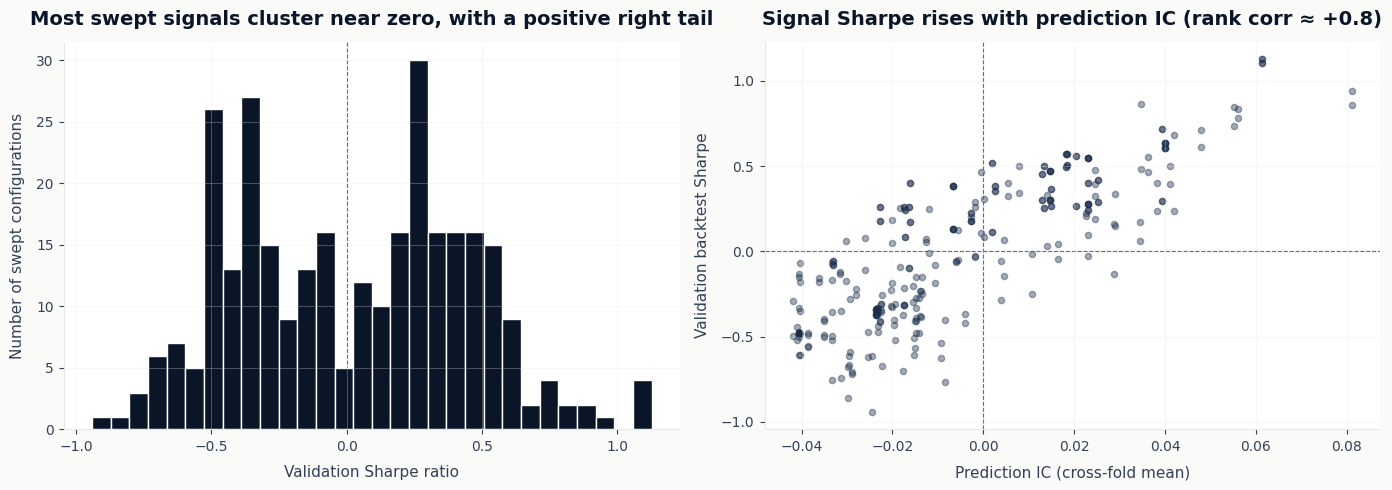

In [12]:
import matplotlib.pyplot as plt

from utils.style import COLORS, apply_ml4t_style, zero_line

apply_ml4t_style()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Sharpe distribution histogram
all_signal = explorer.best(stage="signal", top_n=9999)
if not all_signal.is_empty():
    axes[0].hist(all_signal["sharpe"].to_numpy(), bins=30, color=COLORS["blue"], edgecolor="white")
    zero_line(axes[0], at=0.0, axis="x")
    axes[0].set_xlabel("Validation Sharpe ratio")
    axes[0].set_ylabel("Number of swept configurations")
    axes[0].set_title("Most swept signals cluster near zero, with a positive right tail")

    # IC vs Sharpe
    ic = all_signal["ic_mean"].fill_null(0).to_numpy()
    sh = all_signal["sharpe"].to_numpy()
    axes[1].scatter(ic, sh, alpha=0.4, s=20, color=COLORS["slate"])
    zero_line(axes[1], at=0.0, axis="y")
    zero_line(axes[1], at=0.0, axis="x")
    axes[1].set_xlabel("Prediction IC (cross-fold mean)")
    axes[1].set_ylabel("Validation backtest Sharpe")
    axes[1].set_title("Signal Sharpe rises with prediction IC (rank corr ≈ +0.8)")

fig.tight_layout()
fig.show()

### Deflated Sharpe Ratio

The DSR corrects observed Sharpe ratios for the number of strategies tested.
A strategy that looks good after testing hundreds of configurations may simply
be the best of many noise realizations. With a narrow 30-product universe,
fewer independent bets are available, which increases the importance of
correcting for selection bias when comparing across many model configurations.

$$DSR = \Phi\left[\frac{(\hat{SR} - SR^*) \sqrt{T-1}}{\sqrt{1 - \hat{\gamma}_3 \hat{SR} + \frac{\hat{\gamma}_4 - 1}{4} \hat{SR}^2}}\right]$$

In [13]:
from case_studies.utils.backtest_loaders import print_stage_dsr_summary

print_stage_dsr_summary(explorer, top_n=20, head=10)


--- DSR @ signal (K=20) ---
shape: (10, 21)
┌─────────────┬────────────┬────────────┬────────┬───┬────────────┬────────────┬────────────┬──────┐
│ source      ┆ family     ┆ label      ┆ sharpe ┆ … ┆ ras_leader ┆ ras_pvalue ┆ reality_ch ┆ pbo  │
│ ---         ┆ ---        ┆ ---        ┆ ---    ┆   ┆ ---        ┆ ---        ┆ eck_pvalue ┆ ---  │
│ str         ┆ str        ┆ str        ┆ f64    ┆   ┆ f64        ┆ null       ┆ ---        ┆ f64  │
│             ┆            ┆            ┆        ┆   ┆            ┆            ┆ null       ┆      │
╞═════════════╪════════════╪════════════╪════════╪═══╪════════════╪════════════╪════════════╪══════╡
│ latent_fact ┆ latent_fac ┆ fwd_ret_21 ┆ 1.1263 ┆ … ┆ 0.7826     ┆ null       ┆ null       ┆ 0.4  │
│ ors/sdf     ┆ tors       ┆ d          ┆        ┆   ┆            ┆            ┆            ┆      │
│ latent_fact ┆ latent_fac ┆ fwd_ret_21 ┆ 1.1263 ┆ … ┆ null       ┆ null       ┆ null       ┆ null │
│ ors/sdf     ┆ tors       ┆ d          ┆     

### Sharpe Progression Preview

For the best signal-stage prediction, show how Sharpe changes across
pipeline stages. The signal-stage Sharpe (+1.126 for the SDF model on
`fwd_ret_21d`) provides the baseline; the allocation and cost stages
reveal whether portfolio sizing methods and realistic transaction costs
erode or preserve this edge.

In [14]:
if not top.is_empty():
    best_pred = top["prediction_hash"][0]
    prog = explorer.progression(best_pred)
    if not prog.is_empty():
        print(f"\nSharpe progression for best prediction ({top['source'][0]}):")
        print(prog.select("stage", "sharpe", "cagr", "max_drawdown"))


Sharpe progression for best prediction (latent_factors/sdf):
shape: (4, 4)
┌──────────────────┬──────────┬──────────┬──────────────┐
│ stage            ┆ sharpe   ┆ cagr     ┆ max_drawdown │
│ ---              ┆ ---      ┆ ---      ┆ ---          │
│ str              ┆ f64      ┆ f64      ┆ f64          │
╞══════════════════╪══════════╪══════════╪══════════════╡
│ signal           ┆ 1.126253 ┆ 0.24295  ┆ -0.187723    │
│ allocation       ┆ 1.189192 ┆ 0.214807 ┆ -0.165761    │
│ cost_sensitivity ┆ 1.236469 ┆ 0.224628 ┆ -0.16162     │
│ risk_overlay     ┆ 1.232756 ┆ 0.200016 ┆ -0.157733    │
└──────────────────┴──────────┴──────────┴──────────────┘


## Key Takeaways

1. **IC and Sharpe agree on this panel**: the latent-factor SDF model -
   the one family whose IC clears zero under HAC inference (+0.042 on the
   5-day label, +0.070 daily-pooled on the 21-day variant) - is also the
   signal-stage Sharpe leader at 1.126 [+0.221, +2.034] (PSR p=0.006).
   Across all 302 signal backtests, prediction IC and backtest Sharpe
   rank-correlate at ≈ +0.8: better prediction buys better trading here,
   the opposite of the usual IC-vs-Sharpe disconnect.
2. **The leader survives selection-bias correction - but not
   comfortably**: its deflated Sharpe is +0.040 (DSR p=0.013), above the
   selection's expected-max of +0.030, so the edge is distinguishable from
   the best-of-many-noise draw. A PBO of 0.40 still flags meaningful
   overfit probability - with only 30 products the panel offers few
   independent bets, so the correction matters.
3. With only 30 products, selection-bias correction (DSR) matters more
   than in broader equity universes - fewer independent bets increase the
   probability that a good-looking configuration is a noise draw.
4. The weekly cadence produces far fewer rebalances than daily strategies,
   which benefits cost robustness in Ch18.
5. **The signal-stage leader is a preview, not the final pick**: Ch17
   selects the carrier by cross-stage validation Sharpe, where the GBM
   `leaves_7_huber` / `fwd_ret_5d` lineage ultimately edges ahead
   (risk-overlay Sharpe 1.264). The winner of the full pipeline need not
   be the signal-stage leader.

**Next:** Ch17 allocation tests whether portfolio sizing methods interact
meaningfully with these signals given the narrow 30-product cross-section.